# Visualização On-Chain do Bitcoin — Padrão Acadêmico

Este notebook carrega o dataset enriquecido gerado por `blockchain_explorer.ipynb` e gera 15 gráficos com padrão acadêmico para TCC.

**Dataset**: `files/blockchain_com/btc_onchain_enriched.csv`  
**Biblioteca**: `matplotlib` (sem seaborn, sem cores manuais)  
**Exportação**: PNG 300 dpi em `files/blockchain_com/plots/`
**Período**: 2016-01-01 a 2026-01-01

### Gráficos

| # | Gráfico | Tipo |
|---|---|---|
| 1 | Preço do Bitcoin (2016–2026, log scale) | Linha |
| 2 | Transações vs Preço | **Área** + linha |
| 3 | Endereços Ativos vs Preço | Linha dual-axis |
| 4 | Criação de UTXOs vs Preço | **Barra** (±) + linha |
| 5 | Volume em BTC vs Preço | **Área** + linha |
| 6 | Volume em USD vs Preço | **Área** + linha |
| 7 | Hashrate vs Preço | Linha dual-axis (log) |
| 8 | Dificuldade vs Preço | Linha dual-axis (log) |
| 9 | Receita dos Mineradores (USD) vs Preço | Linha dual-axis (log) |
| 10 | Receita dos Mineradores (BTC) vs Preço | Linha dual-axis (log) |
| 11 | Decomposição da Receita (block rewards + fees) | Linha (log) |
| 12 | Receita dos Mineradores (BTC) | Linha (log) |
| 13 | Faixa de Custo de Produção vs Preço | Linha + banda |
| 14 | Heatmap de Correlação (Pearson) | Matriz |
| 15 | Ranking de Correlação com Preço | **Barra** horizontal |

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path

## 1. Carregamento do Dataset Enriquecido

O dataset já contém preço, métricas on-chain e métricas derivadas (custo de produção, custo de eletricidade, criação de UTXOs).  
Gerado por `blockchain_explorer.ipynb`.  
Os dados diários são agregados para **frequência semanal** (resample `W`) para reduzir ruído e facilitar a visualização de tendências.

In [63]:
DATA_PATH = "files/blockchain_com/btc_onchain_enriched.csv"
PLOTS_DIR = "files/blockchain_com/plots"
DPI = 300
DATE_START = "2016-01-01"
DATE_END = "2026-01-01"

os.makedirs(PLOTS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Decomposição da receita: block rewards vs fees (antes do resample para maior precisão)
if "fees_usd" not in df.columns:
    df["fees_usd"] = df["miners_revenue"] - (df["daily_btc_mined"] * df["price_usd"])
    df["fees_usd"] = df["fees_usd"].clip(lower=0)
if "block_rewards_usd" not in df.columns:
    df["block_rewards_usd"] = df["miners_revenue"] - df["fees_usd"]

# Filtrar período padronizado ANTES do resample
df = df[(df["date"] >= DATE_START) & (df["date"] <= DATE_END)]

df = df.set_index("date").resample("W").agg({
    "price_usd": "last",
    "transactions": "mean",
    "active_addresses": "mean",
    "hashrate": "mean",
    "difficulty": "last",
    "miners_revenue": "sum",
    "fees_usd": "sum",
    "block_rewards_usd": "sum",
    "transaction_volume_btc": "sum",
    "transaction_volume_usd": "sum",
    "utxo_count": "last",
    "total_btc": "last",
    "utxo_creation": "sum",
    "cost_per_btc": "mean",
    "electricity_cost_per_btc": "mean",
}).reset_index()

# Remover semanas parciais nas bordas (resample "W" gera semana incompleta
# no início/fim do período — métricas "sum" ficam artificialmente baixas)
df = df.iloc[1:-1].reset_index(drop=True)

# Receita em BTC (derivada: receita USD / preço)
df["miners_revenue_btc"] = df["miners_revenue"] / df["price_usd"]


print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
print(f"Período: {df['date'].min().date()} a {df['date'].max().date()}")

Shape: (521, 17)
Colunas: ['date', 'price_usd', 'transactions', 'active_addresses', 'hashrate', 'difficulty', 'miners_revenue', 'fees_usd', 'block_rewards_usd', 'transaction_volume_btc', 'transaction_volume_usd', 'utxo_count', 'total_btc', 'utxo_creation', 'cost_per_btc', 'electricity_cost_per_btc', 'miners_revenue_btc']
Período: 2016-01-10 a 2025-12-28


## 5. Configuração Visual (Padrão Acadêmico — Checklist MBA USP/Esalq)

Conformidade com o checklist de formatação do TCC:
- **Sem borda**, sem preenchimento, sem linhas de grade em gráficos de barra
- Eixos na cor **preta**, largura **1.5 pt**
- Labels dos eixos **sem negrito**
- Fonte Arial tamanho 11 (nos PNGs exportados)
- Grid leve (tracejado) apenas em gráficos de linha/área

In [64]:
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",
    "axes.labelsize": 11,
    "axes.labelweight": "normal",     # Checklist: labels NÃO negrito
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,           # Checklist: sem borda e sem preenchimento na legenda
    "axes.grid": False,               # Checklist: sem linhas de grade
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.5,            # Checklist: eixos pretos 1.5pt
    "axes.edgecolor": "black",        # Checklist: eixos na cor preta
    "xtick.color": "black",
    "ytick.color": "black",
})

# Cores do ciclo padrão do matplotlib
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## 6. Funções Reutilizáveis

In [65]:
def format_y_axis(ax, scale="auto"):
    """Formata eixo Y para valores grandes (K, M, B, T)."""
    if scale == "auto":
        ymin, ymax = ax.get_ylim()
        ref = max(abs(ymin), abs(ymax))
        if ref >= 1e12:
            scale = "T"
        elif ref >= 1e9:
            scale = "B"
        elif ref >= 1e6:
            scale = "M"
        elif ref >= 1e3:
            scale = "K"
        else:
            return

    divisors = {"T": 1e12, "B": 1e9, "M": 1e6, "K": 1e3}
    d = divisors[scale]
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/d:,.1f}{scale}" if d >= 1e6 else f"{x/d:,.0f}{scale}"
    ))


def _log_tick_formatter(x, _):
    """Formatter para eixo log — abrevia com sufixos K/M/B/T em qualquer magnitude."""
    if x <= 0:
        return ""
    if x >= 1e12:
        return f"{x/1e12:,.1f}T"
    elif x >= 1e9:
        return f"{x/1e9:,.1f}B"
    elif x >= 1e6:
        return f"{x/1e6:,.1f}M"
    elif x >= 1e3:
        return f"{x/1e3:,.0f}K"
    elif x >= 1:
        return f"{x:,.0f}"
    else:
        return f"{x:.2f}"


def save_plot(fig, filename):
    """Salva figura em PNG com alta resolução."""
    path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white")
    print(f"  Salvo: {path}")


def _setup_price_axis(ax2, data, price_log=True):
    """Configura eixo direito (preço BTC) — reutilizado em todos os dual-axis."""
    c2 = COLORS[1]
    line2 = ax2.plot(data["date"], data["price_usd"], linewidth=0.8, color=c2, alpha=0.7, label="Preço BTC (USD)")
    ax2.set_ylabel("Preço BTC (USD)", color=c2)
    ax2.tick_params(axis="y", labelcolor=c2)
    ax2.spines["right"].set_visible(True)
    ax2.spines["right"].set_color("black")
    ax2.spines["right"].set_linewidth(1.5)
    if price_log:
        ax2.set_yscale("log")
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"${x:,.0f}" if x >= 1 else f"${x:.2f}"
        ))
    else:
        format_y_axis(ax2)
    return line2


def plot_metric_vs_price(data, metric_col, metric_label, metric_ylabel, title,
                         filename, price_log=True, metric_log=False, note=None):
    """
    Gráfico dual-axis LINHA: métrica on-chain (esquerdo) vs preço BTC (direito).
    Checklist: sem grid, sem preenchimento, sem borda, legenda acima do título.
    """
    fig, ax1 = plt.subplots()
    c1 = COLORS[0]

    # Eixo esquerdo — métrica on-chain (linha)
    line1 = ax1.plot(data["date"], data[metric_col], linewidth=0.8, color=c1, label=metric_label)
    ax1.set_xlabel("Data")
    ax1.set_ylabel(metric_ylabel, color=c1)
    ax1.tick_params(axis="y", labelcolor=c1)
    if metric_log:
        ax1.set_yscale("log")
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(_log_tick_formatter))
    else:
        format_y_axis(ax1)

    # Eixo direito — preço BTC
    ax2 = ax1.twinx()
    line2 = _setup_price_axis(ax2, data, price_log)

    # Legenda combinada (acima do título)
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, bbox_to_anchor=(0.5, 1.15), loc="upper center", ncol=2)

    ax1.set_title(title)

    if note:
        fig.text(0.5, -0.02, note, ha="center", fontsize=9, style="italic", color="gray")

    fig.autofmt_xdate()
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()


def plot_area_vs_price(data, metric_col, metric_label, metric_ylabel, title,
                       filename, price_log=True, note=None):
    """
    Gráfico dual-axis ÁREA: métrica on-chain preenchida (esquerdo) vs preço BTC (direito).
    Ideal para volume, transações, receita — dados positivos com ruído diário.
    Checklist: sem grid, sem preenchimento, sem borda, legenda acima do título.
    """
    fig, ax1 = plt.subplots()
    c1 = COLORS[0]

    # Eixo esquerdo — área preenchida
    ax1.fill_between(data["date"], data[metric_col], alpha=0.35, color=c1, label=metric_label)
    ax1.plot(data["date"], data[metric_col], linewidth=0.4, color=c1, alpha=0.6)
    ax1.set_xlabel("Data")
    ax1.set_ylabel(metric_ylabel, color=c1)
    ax1.tick_params(axis="y", labelcolor=c1)
    format_y_axis(ax1)

    # Eixo direito — preço BTC
    ax2 = ax1.twinx()
    line2 = _setup_price_axis(ax2, data, price_log)

    # Legenda — combinar patch de área + linha de preço (acima do título)
    handles1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(handles1 + line2, labels1 + [l.get_label() for l in line2],
               bbox_to_anchor=(0.5, 1.15), loc="upper center", ncol=2)

    ax1.set_title(title)

    if note:
        fig.text(0.5, -0.02, note, ha="center", fontsize=9, style="italic", color="gray")

    fig.autofmt_xdate()
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()


def plot_bar_vs_price(data, metric_col, metric_label, metric_ylabel, title,
                      filename, price_log=True, note=None):
    """
    Gráfico dual-axis BARRA: métrica on-chain (esquerdo) vs preço BTC (direito).
    Ideal para ΔUTXOs (positivo/negativo).
    Checklist: sem borda nas barras, sem grid, sem preenchimento de fundo, legenda acima do título.
    """
    fig, ax1 = plt.subplots()

    vals = data[metric_col].values
    colors_bar = np.where(vals >= 0, COLORS[0], COLORS[3])

    # Eixo esquerdo — barras (sem edgecolor = "sem borda")
    ax1.bar(data["date"], vals, width=7.0, color=colors_bar, alpha=0.7,
            edgecolor="none", label=metric_label)
    ax1.set_xlabel("Data")
    ax1.set_ylabel(metric_ylabel, color=COLORS[0])
    ax1.tick_params(axis="y", labelcolor=COLORS[0])
    format_y_axis(ax1)
    ax1.axhline(0, color="black", linewidth=0.5, zorder=1)

    # Eixo direito — preço BTC
    ax2 = ax1.twinx()
    line2 = _setup_price_axis(ax2, data, price_log)

    # Legenda (acima do título)
    handles1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(handles1 + line2, labels1 + [l.get_label() for l in line2],
               bbox_to_anchor=(0.5, 1.15), loc="upper center", ncol=2)

    ax1.set_title(title)

    if note:
        fig.text(0.5, -0.02, note, ha="center", fontsize=9, style="italic", color="gray")

    fig.autofmt_xdate()
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

---

## Gráfico 1 — Preço do Bitcoin (2016–2026)

Escala logarítmica para visualizar ciclos de alta (bull) e baixa (bear) com amplitudes muito distintas.  
Serve como referência visual para contextualizar todos os gráficos seguintes.

  Salvo: files/blockchain_com/plots\01_price_btc_log.png


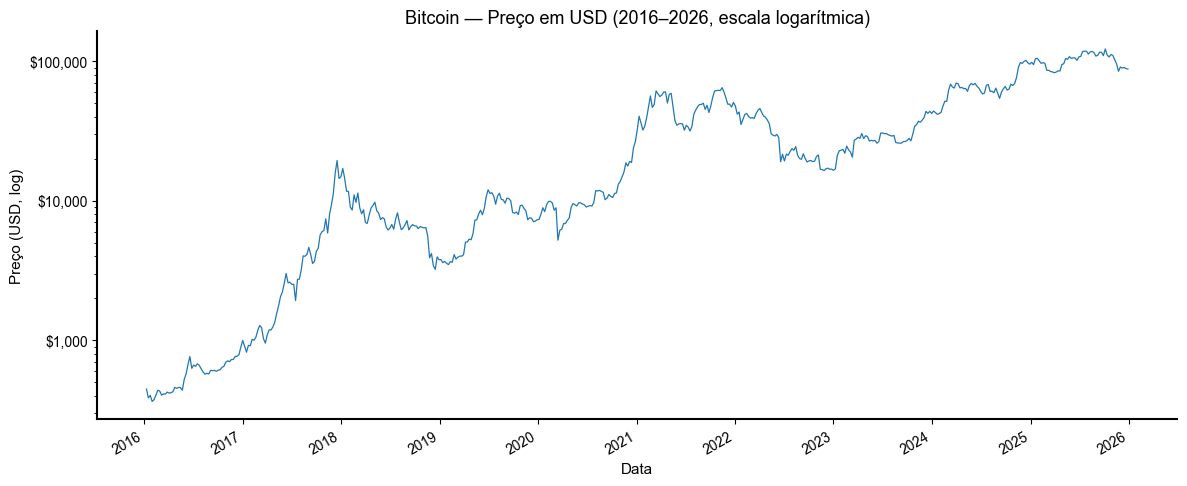

In [66]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["price_usd"], linewidth=0.9)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}" if x >= 1 else f"${x:.2f}"
))
ax.set_title("Bitcoin — Preço em USD (2016–2026, escala logarítmica)")
ax.set_xlabel("Data")
ax.set_ylabel("Preço (USD, log)")
fig.autofmt_xdate()
fig.tight_layout()
save_plot(fig, "01_price_btc_log.png")
plt.show()

---

## Gráfico 2 — Número de Transações vs Preço

Média semanal de transações confirmadas vs preço.  
Espera-se aumento de transações em períodos de alta, mas o batching de exchanges pode distorcer a relação.

  Salvo: files/blockchain_com/plots\02_transactions_vs_price.png


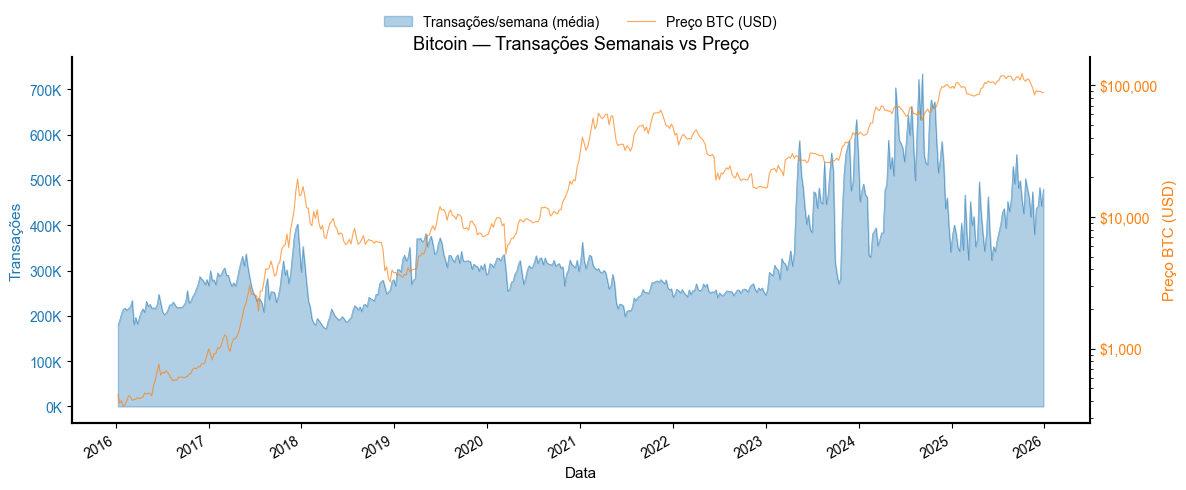

In [67]:
plot_area_vs_price(
    df, "transactions", "Transações/semana (média)", "Transações",
    title="Bitcoin — Transações Semanais vs Preço",
    filename="02_transactions_vs_price.png",
)

---

## Gráfico 3 — Endereços Ativos vs Preço

Média semanal de endereços únicos que participaram de transações vs preço.  
⚠ **Proxy**: endereços ativos ≠ usuários únicos. Um usuário pode ter múltiplos endereços; exchanges consolidam milhões de usuários em poucos endereços.

  Salvo: files/blockchain_com/plots\03_active_addresses_vs_price.png


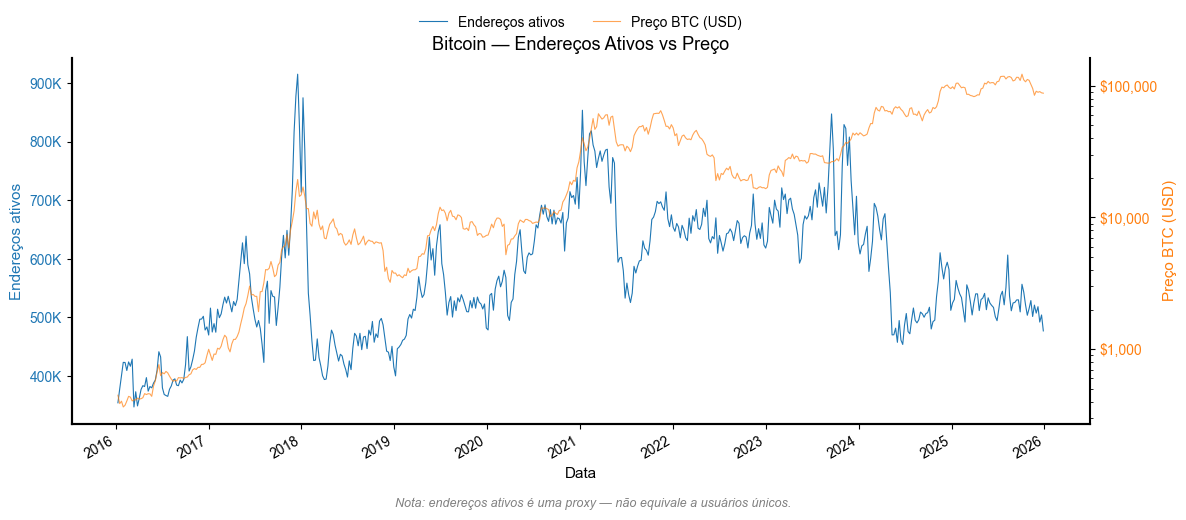

In [68]:
plot_metric_vs_price(
    df, "active_addresses", "Endereços ativos", "Endereços ativos",
    title="Bitcoin — Endereços Ativos vs Preço",
    filename="03_active_addresses_vs_price.png",
    note="Nota: endereços ativos é uma proxy — não equivale a usuários únicos.",
)

---

## Gráfico 4 — Criação de UTXOs vs Preço

Variação semanal líquida do UTXO set. Valores positivos indicam mais UTXOs sendo criados do que consumidos na semana.  
Picos podem indicar atividade de exchanges, consolidações ou ataques de spam.

  Salvo: files/blockchain_com/plots\04_utxo_creation_vs_price.png


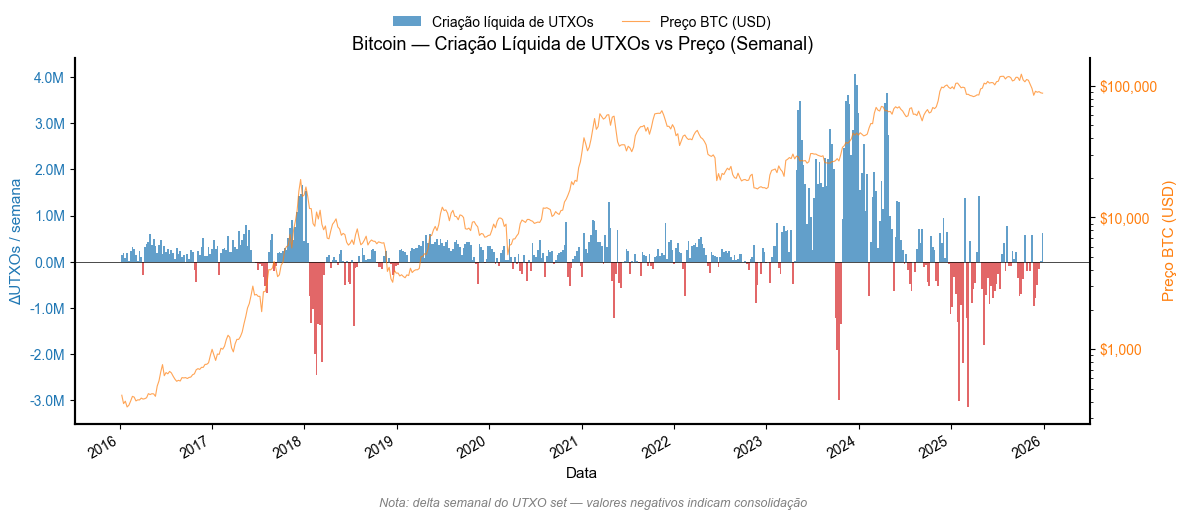

In [69]:
plot_bar_vs_price(
    df, "utxo_creation", "Criação líquida de UTXOs", "ΔUTXOs / semana",
    title="Bitcoin — Criação Líquida de UTXOs vs Preço (Semanal)",
    filename="04_utxo_creation_vs_price.png",
    note="Nota: delta semanal do UTXO set — valores negativos indicam consolidação",
)

---

## Gráfico 5 — Volume em BTC vs Preço

Volume semanal estimado de BTC transferidos on-chain.  
Mostra o uso "nativo" da rede em sua unidade de conta. Picos podem indicar movimentação de baleias ou atividade institucional.

  Salvo: files/blockchain_com/plots\05_volume_btc_vs_price.png


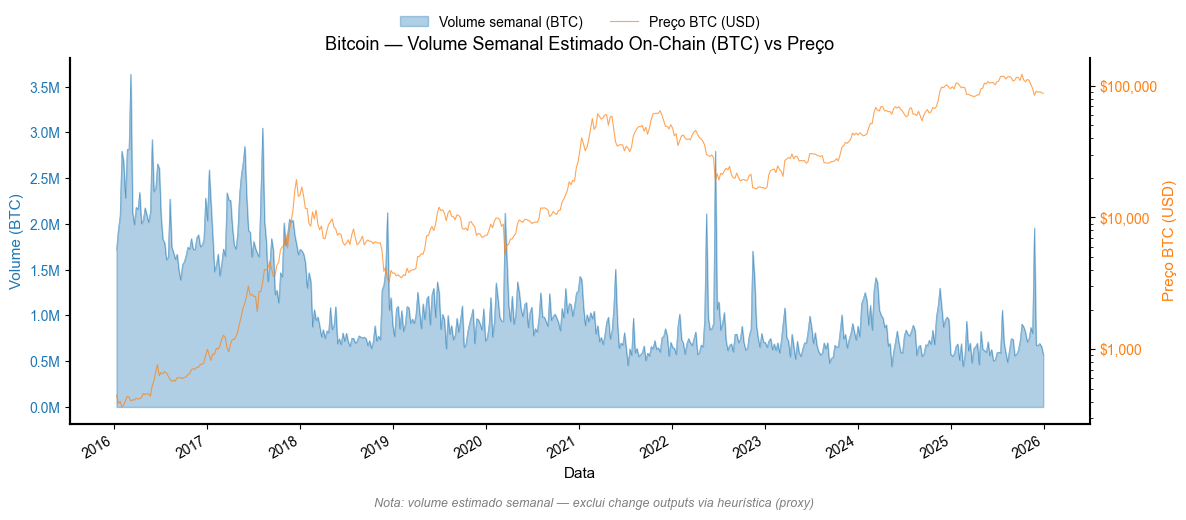

In [70]:
plot_area_vs_price(
    df, "transaction_volume_btc", "Volume semanal (BTC)", "Volume (BTC)",
    title="Bitcoin — Volume Semanal Estimado On-Chain (BTC) vs Preço",
    filename="05_volume_btc_vs_price.png",
    note="Nota: volume estimado semanal — exclui change outputs via heurística (proxy)",
)

---

## Gráfico 6 — Volume em USD vs Preço

Volume semanal on-chain convertido para USD.  
Representa a demanda econômica real — captura tanto a quantidade de BTC transferidos quanto o preço do momento.

  Salvo: files/blockchain_com/plots\06_volume_usd_vs_price.png


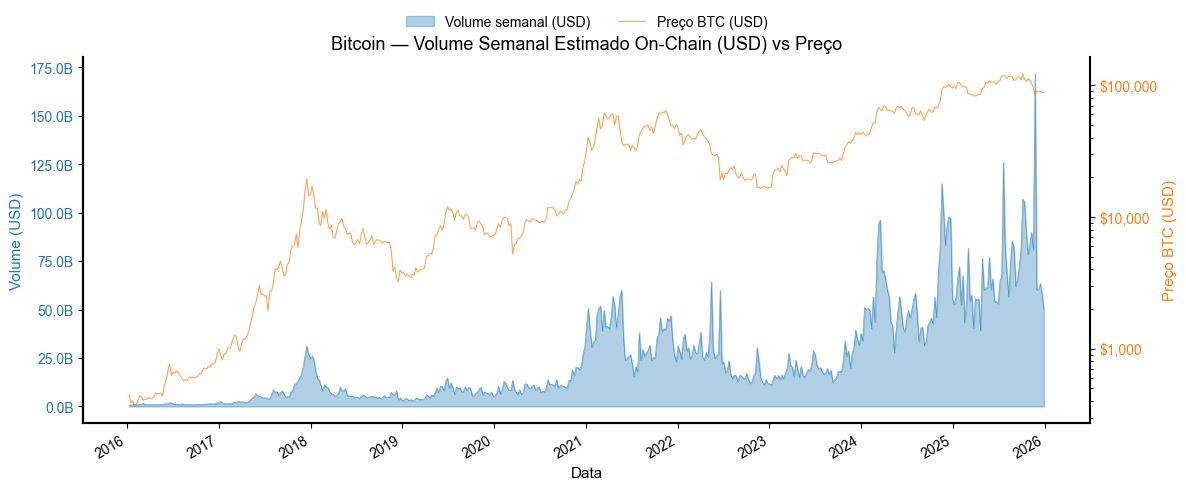

In [71]:
plot_area_vs_price(
    df, "transaction_volume_usd", "Volume semanal (USD)", "Volume (USD)",
    title="Bitcoin — Volume Semanal Estimado On-Chain (USD) vs Preço",
    filename="06_volume_usd_vs_price.png",
)

---

## Gráfico 7 — Hashrate vs Preço

Hashrate estimado da rede vs preço — relação clássica.  
O hashrate tipicamente segue o preço com lag (mineradores respondem a incentivos econômicos com atraso de semanas/meses).  
Escala log no hashrate — cresce várias ordens de grandeza.

  Salvo: files/blockchain_com/plots\07_hashrate_vs_price.png


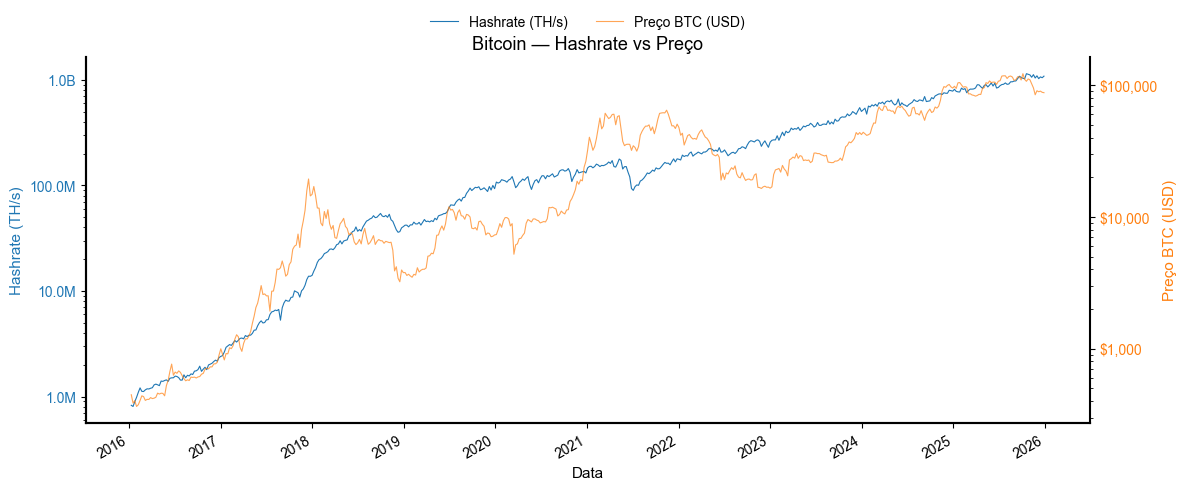

In [72]:
plot_metric_vs_price(
    df, "hashrate", "Hashrate (TH/s)", "Hashrate (TH/s)",
    title="Bitcoin — Hashrate vs Preço",
    filename="07_hashrate_vs_price.png",
    # Hashrate varia de ~300K TH/s a centenas de bilhões:
    # escala log necessária para visualizar toda a série
    metric_log=True,
)

---

## Gráfico 8 — Dificuldade vs Preço

Complemento do hashrate — a dificuldade ajusta-se a cada ~2016 blocos (~2 semanas) para manter blocos a cada ~10 min.  
Escala log pela mesma razão do hashrate.

  Salvo: files/blockchain_com/plots\08_difficulty_vs_price.png


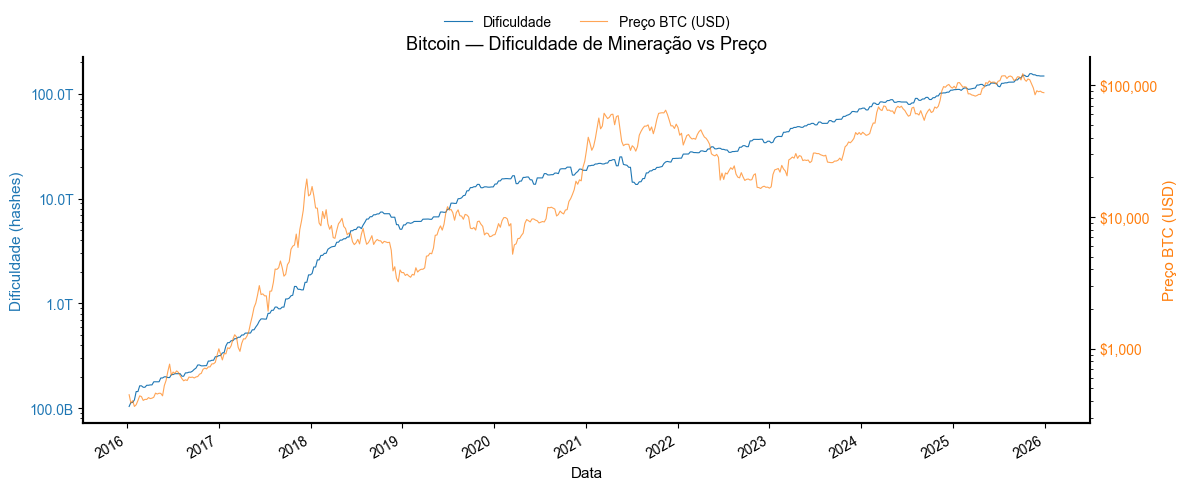

In [73]:
plot_metric_vs_price(
    df, "difficulty", "Dificuldade", "Dificuldade (hashes)",
    title="Bitcoin — Dificuldade de Mineração vs Preço",
    filename="08_difficulty_vs_price.png",
    metric_log=True,
)

---

## Gráfico 9 — Receita dos Mineradores vs Preço

Receita semanal total dos mineradores = recompensa de bloco + taxas de transação, em USD.  
Reflete incentivos econômicos — halvings são visíveis como quedas súbitas.

  Salvo: files/blockchain_com/plots\09_miners_revenue_vs_price.png


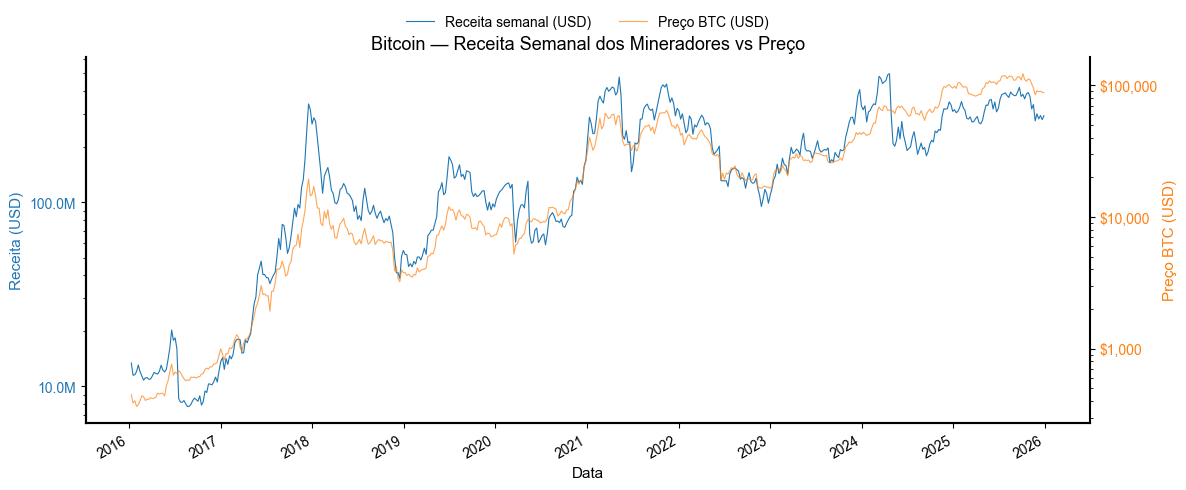

In [74]:
plot_metric_vs_price(
    df, "miners_revenue", "Receita semanal (USD)", "Receita (USD)",
    title="Bitcoin — Receita Semanal dos Mineradores vs Preço",
    filename="09_miners_revenue_vs_price.png",
    metric_log=True,
)

---

## Gráfico 10 — Receita dos Mineradores (BTC) vs Preço

Receita semanal dos mineradores em BTC (receita USD ÷ preço), comparada ao preço do Bitcoin.  
Isola o efeito do preço e evidencia os halvings como degraus nítidos (~50% de queda na recompensa).  
Diferente do Gráfico 9 (receita em USD), que é amplificada pelos ciclos de preço.

  Salvo: files/blockchain_com/plots\10_miners_revenue_btc_vs_price.png


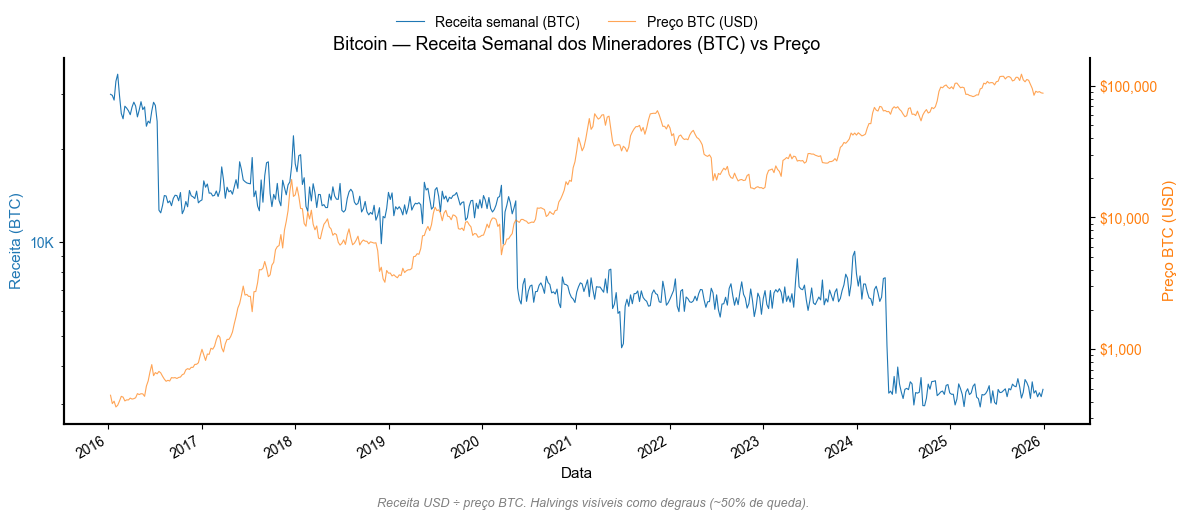

In [75]:
plot_metric_vs_price(
    df, "miners_revenue_btc", "Receita semanal (BTC)", "Receita (BTC)",
    title="Bitcoin — Receita Semanal dos Mineradores (BTC) vs Preço",
    filename="10_miners_revenue_btc_vs_price.png",
    metric_log=True,
    note="Receita USD ÷ preço BTC. Halvings visíveis como degraus (~50% de queda).",
)

---

## Gráfico 11 — Decomposição da Receita dos Mineradores

Decomposição da receita semanal em duas componentes:

- **Recompensa de bloco** (azul claro): BTC emitidos × preço — dominante, cai ~50% a cada halving
- **Taxas de transação** (azul escuro): receita total − recompensa — cresce em momentos de congestionamento

Sem eixo de preço — foco exclusivo na composição da receita. Escala log para visualizar ambas as séries na mesma magnitude.

  Salvo: files/blockchain_com/plots\11_miners_revenue_decomposed.png


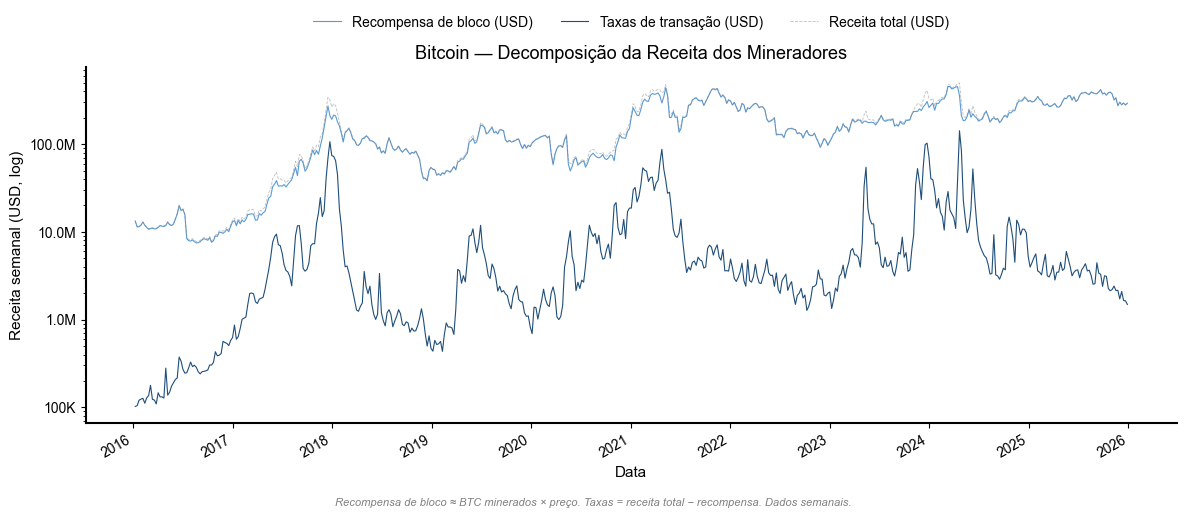

In [76]:
# --- Gráfico 11: Decomposição da receita (block rewards + fees) ---
fig, ax = plt.subplots()

ax.plot(df["date"], df["block_rewards_usd"], linewidth=0.8,
        color="#5B9BD5", label="Recompensa de bloco (USD)")
ax.plot(df["date"], df["fees_usd"], linewidth=0.8,
        color="#1F4E79", label="Taxas de transação (USD)")
ax.plot(df["date"], df["miners_revenue"], linewidth=0.6,
        color="gray", linestyle="--", alpha=0.5, label="Receita total (USD)")

ax.set_xlabel("Data")
ax.set_ylabel("Receita semanal (USD, log)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(_log_tick_formatter))

# Legenda (acima do título)
ax.legend(bbox_to_anchor=(0.5, 1.18), loc="upper center", ncol=3)

ax.set_title("Bitcoin — Decomposição da Receita dos Mineradores")

fig.text(0.5, -0.02,
         "Recompensa de bloco ≈ BTC minerados × preço. "
         "Taxas = receita total − recompensa. Dados semanais.",
         ha="center", fontsize=8, style="italic", color="gray")

fig.autofmt_xdate()
fig.tight_layout()
save_plot(fig, "11_miners_revenue_decomposed.png")
plt.show()

---

## Gráfico 12 — Receita dos Mineradores em BTC

Receita semanal dos mineradores convertida para BTC (receita USD ÷ preço).
Isolada do efeito do preço, mostra a recompensa real em BTC — halvings aparecem como degraus nítidos.
Escala logarítmica para visualizar toda a série histórica.

  Salvo: files/blockchain_com/plots\12_miners_revenue_btc.png


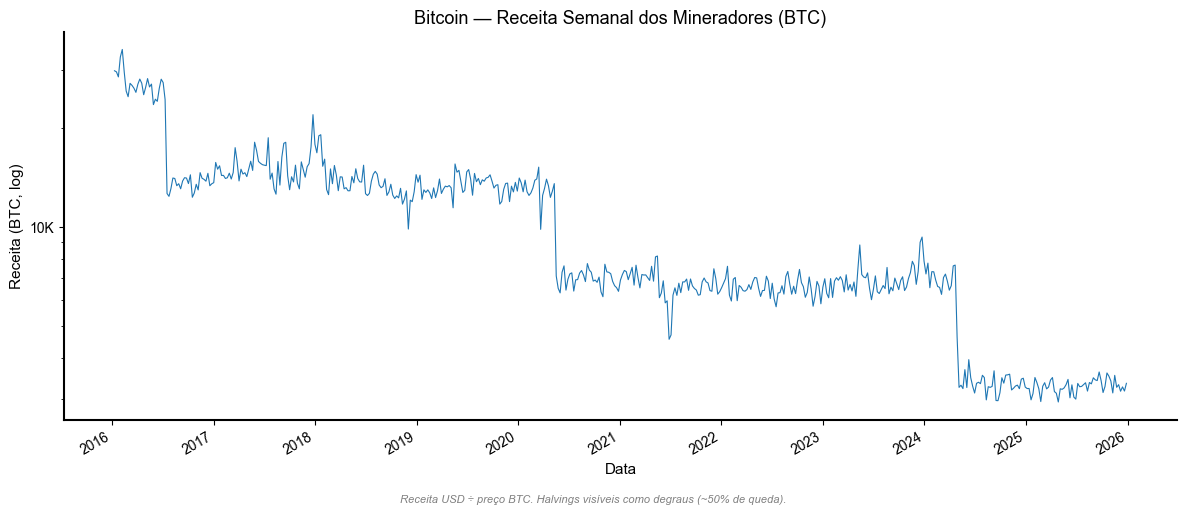

In [77]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["miners_revenue_btc"], linewidth=0.8, color=COLORS[0])
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(_log_tick_formatter))
ax.set_title("Bitcoin — Receita Semanal dos Mineradores (BTC)")
ax.set_xlabel("Data")
ax.set_ylabel("Receita (BTC, log)")
fig.text(0.5, -0.02,
         "Receita USD ÷ preço BTC. Halvings visíveis como degraus (~50% de queda).",
         ha="center", fontsize=8, style="italic", color="gray")
fig.autofmt_xdate()
fig.tight_layout()
save_plot(fig, "12_miners_revenue_btc.png")
plt.show()

---

## Gráfico 13 — Faixa de Custo de Produção vs Preço

**O mais importante do bloco.** Possível "price floor" visual.

A Figura 13 compara o preço de mercado do Bitcoin com uma **faixa estimada de custo de produção** (USD, escala logarítmica):

- **Piso** (custo mínimo): custo de eletricidade por BTC — calculado via hashrate da rede × eficiência ASIC × $0.05/kWh
- **Teto** (custo total estimado): `custo_eletricidade / 0.60` — baseado no consenso de que eletricidade representa ~60% do custo total de mineração (ref. CBECI, Stoll et al. 2019). Os outros ~40% incluem depreciação de hardware (ASICs), refrigeração, infraestrutura e mão de obra.

A região preenchida entre piso e teto representa a **zona provável de custo de produção**. Quando o preço cai dentro ou abaixo dessa faixa, mineradores menos eficientes desligam → hashrate cai → dificuldade ajusta → novo equilíbrio.

⚠ **Limitações**: Eficiência ASIC interpolada (S5→S21). Eletricidade = média global $0.05/kWh (CBECI). Proporção 60% é média — varia de 50% (operações com hardware antigo) a 80% (operações com energia subsidiada).

  Salvo: files/blockchain_com/plots\13_cost_production_vs_price.png


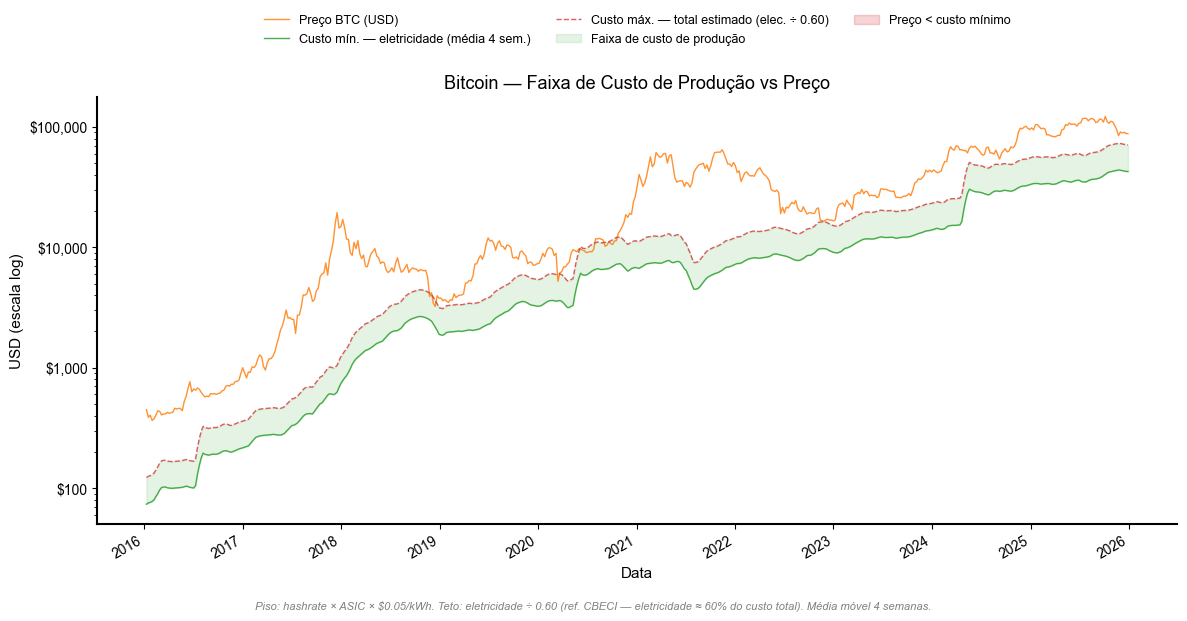

In [78]:
# --- Gráfico 13: preço vs faixa de custo de produção (piso elétrico + teto total) ---
fig, ax = plt.subplots(figsize=(12, 6))

# Suavizar custos (rolling 4 semanas)
elec_smooth = df["electricity_cost_per_btc"].rolling(4, min_periods=1).mean()
total_cost_upper = elec_smooth / 0.60  # eletricidade ≈ 60% do custo total (ref. CBECI)

# Preço BTC
ax.plot(df["date"], df["price_usd"], linewidth=1.0, color=COLORS[1],
        alpha=0.85, label="Preço BTC (USD)")

# Piso — custo de eletricidade
ax.plot(df["date"], elec_smooth, linewidth=1.0, color=COLORS[2],
        alpha=0.85, label="Custo mín. — eletricidade (média 4 sem.)")

# Teto — custo total estimado
ax.plot(df["date"], total_cost_upper, linewidth=1.0, color=COLORS[3],
        alpha=0.75, linestyle="--", label="Custo máx. — total estimado (elec. ÷ 0.60)")

# Faixa de custo (banda entre piso e teto)
ax.fill_between(
    df["date"], elec_smooth, total_cost_upper,
    alpha=0.12, color=COLORS[2], label="Faixa de custo de produção",
)

# Região onde preço < custo mínimo (mineração inviável para todos)
ax.fill_between(
    df["date"], df["price_usd"], elec_smooth,
    where=elec_smooth > df["price_usd"],
    alpha=0.20, color=COLORS[3], label="Preço < custo mínimo",
    interpolate=True,
)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}" if x >= 1 else f"${x:.2f}"
))
ax.set_xlabel("Data")
ax.set_ylabel("USD (escala log)")

# Legenda (acima do título)
ax.legend(bbox_to_anchor=(0.5, 1.22), loc="upper center", ncol=3, fontsize=9)

ax.set_title("Bitcoin — Faixa de Custo de Produção vs Preço")

fig.text(0.5, -0.02,
         "Piso: hashrate × ASIC × $0.05/kWh. Teto: eletricidade ÷ 0.60 "
         "(ref. CBECI — eletricidade ≈ 60% do custo total). Média móvel 4 semanas.",
         ha="center", fontsize=8, style="italic", color="gray")

fig.autofmt_xdate()
fig.tight_layout()
save_plot(fig, "13_cost_production_vs_price.png")
plt.show()

---

## Gráfico 14 — Heatmap de Correlação (Pearson)

Matriz de correlação entre as variáveis on-chain selecionadas do dataset, utilizando `matplotlib.imshow`.

**Métricas excluídas por redundância**: `cost_per_btc` (≈ preço por construção), `miners_revenue` (≈ preço × block_reward), `transaction_volume_usd` (≈ volume_btc × preço), `difficulty` (correlação ~1.0 com hashrate, lag de ~2 semanas).

**Nota**: Hashrate e Custo de Eletricidade são mantidos com asterisco (*) para indicar que a causalidade predominante é preço → hashrate → custo, e não o inverso.

  Salvo: files/blockchain_com/plots\14_correlation_heatmap.png


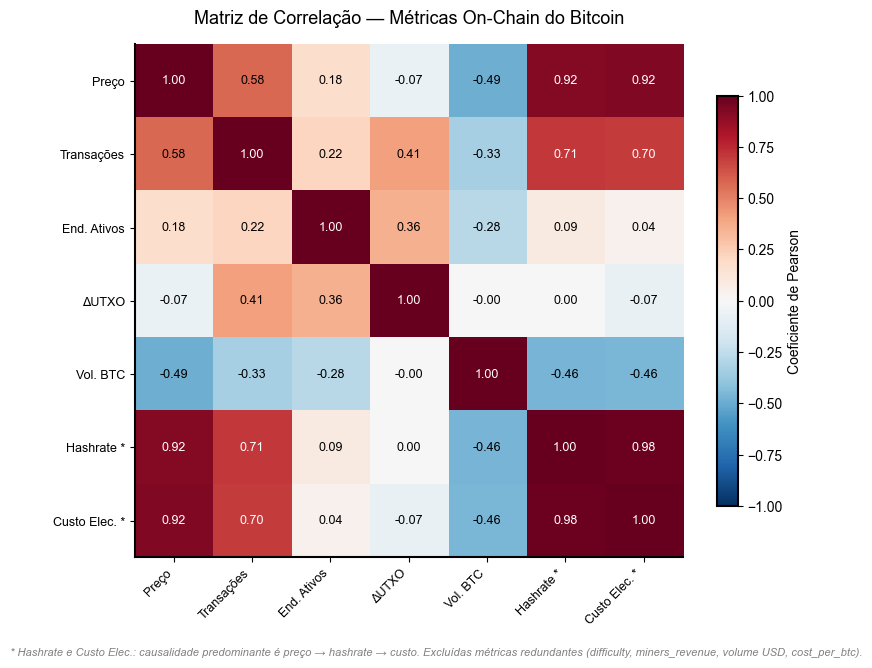

In [79]:
# Selecionar colunas de análise (excluir redundantes com preço)
# Removidos: cost_per_btc, miners_revenue, transaction_volume_usd, difficulty
corr_cols = [
    "price_usd", "transactions", "active_addresses", "utxo_creation",
    "transaction_volume_btc",
    "hashrate", "electricity_cost_per_btc",
]

# Labels curtos para o heatmap
corr_labels = [
    "Preço", "Transações", "End. Ativos", "ΔUTXO",
    "Vol. BTC",
    "Hashrate *", "Custo Elec. *",
]

corr_matrix = df[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

# Ticks e labels
ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_labels, fontsize=9)

# Anotar valores dentro das células
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Coeficiente de Pearson", fontsize=10)

ax.set_title("Matriz de Correlação — Métricas On-Chain do Bitcoin", fontsize=13, pad=15)

fig.text(0.5, -0.02,
         "* Hashrate e Custo Elec.: causalidade predominante é preço → hashrate → custo. "
         "Excluídas métricas redundantes (difficulty, miners_revenue, volume USD, cost_per_btc).",
         ha="center", fontsize=8, style="italic", color="gray")

fig.tight_layout()
save_plot(fig, "14_correlation_heatmap.png")
plt.show()

---

## Gráfico 15 — Ranking de Correlação com Preço

A Figura 15 apresenta o ranking das correlações (Pearson) entre as variáveis on-chain analisadas e o preço do Bitcoin, permitindo identificar de forma direta quais métricas apresentam maior associação com o comportamento do ativo.

**Métricas excluídas por redundância/tautologia**:
- `cost_per_btc` (receita/BTC ≈ preço, ρ ≈ 0.99) — relação tautológica
- `miners_revenue` (≈ preço × block_reward + fees) — derivada diretamente do preço
- `transaction_volume_usd` (≈ volume_btc × preço) — inflada pela conversão cambial
- `difficulty` — correlação ~1.0 com hashrate (lag ~2 semanas), informação redundante

**Métricas dependentes (barras cinza)**: Hashrate e Custo de Eletricidade são mantidos no ranking, mas sinalizados em cinza com asterisco (*). A causalidade predominante é **preço → hashrate → custo**: quando o preço sobe, mais mineradores entram na rede → hashrate cresce → consumo energético aumenta. Essa relação opera com lag de semanas a meses. A exceção ocorre no "price floor", quando o preço cai abaixo do custo de produção e mineradores ineficientes desligam.

  Salvo: files/blockchain_com/plots\15_correlation_ranking.png


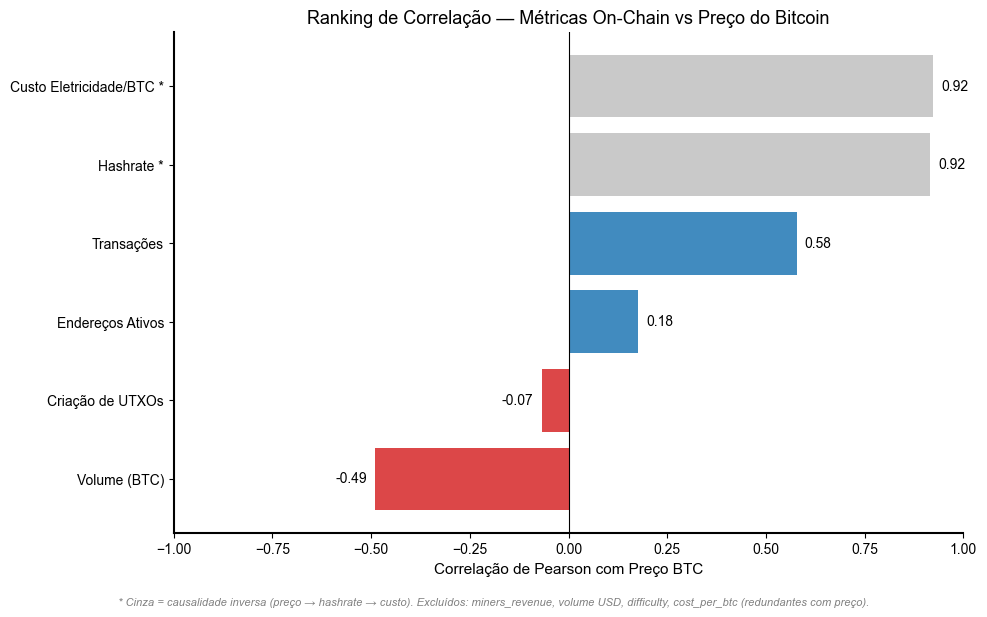

In [80]:
# Correlação de cada variável com o preço
# Excluídos por redundância:
#   - cost_per_btc:            ≈ preço (receita = preço × block_reward)
#   - miners_revenue:          ≈ preço × block_reward + taxas
#   - transaction_volume_usd:  ≈ volume_btc × preço
#   - difficulty:              ≈ hashrate com lag ~2 semanas (corr ~1.0)

# Métricas independentes (não derivadas mecanicamente do preço)
independent_cols = [
    ("transactions",            "Transações"),
    ("active_addresses",        "Endereços Ativos"),
    ("utxo_creation",           "Criação de UTXOs"),
    ("transaction_volume_btc",  "Volume (BTC)"),
]

# Métricas dependentes do preço (preço → hashrate → custo), mas economicamente informativas
dependent_cols = [
    ("hashrate",                "Hashrate *"),
    ("electricity_cost_per_btc","Custo Eletricidade/BTC *"),
]

all_cols = independent_cols + dependent_cols
corr_with_price = {label: df[col].corr(df["price_usd"]) for col, label in all_cols}
ranked = sorted(corr_with_price.items(), key=lambda x: x[1], reverse=True)
labels_r = [r[0] for r in ranked]
values_r = [r[1] for r in ranked]
dep_labels = {label for _, label in dependent_cols}

# Cores: independente positiva = azul, independente negativa = vermelho
# Dependente = cinza (para distinguir visualmente)
bar_colors = []
for label, val in zip(labels_r, values_r):
    if label in dep_labels:
        bar_colors.append("silver")
    elif val >= 0:
        bar_colors.append(COLORS[0])
    else:
        bar_colors.append(COLORS[3])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels_r[::-1], values_r[::-1], color=bar_colors[::-1],
               edgecolor="none", alpha=0.85)

# Anotar valores nas barras
for bar, val in zip(bars, values_r[::-1]):
    x_pos = val + 0.02 if val >= 0 else val - 0.02
    ha = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha=ha, fontsize=10, fontweight="normal")

ax.set_xlabel("Correlação de Pearson com Preço BTC")
ax.set_title("Ranking de Correlação — Métricas On-Chain vs Preço do Bitcoin")
ax.set_xlim(-1, 1)
ax.axvline(0, color="black", linewidth=0.8)

fig.text(0.5, -0.02,
         "* Cinza = causalidade inversa (preço → hashrate → custo). "
         "Excluídos: miners_revenue, volume USD, difficulty, cost_per_btc (redundantes com preço).",
         ha="center", fontsize=8, style="italic", color="gray")

fig.tight_layout()
save_plot(fig, "15_correlation_ranking.png")
plt.show()

---

## Resumo dos Gráficos Exportados

In [81]:
plot_files = sorted(Path(PLOTS_DIR).glob("*.png"))

print(f"Total de gráficos exportados: {len(plot_files)}")
print(f"Diretório: {PLOTS_DIR}/")
print(f"Resolução: {DPI} dpi\n")

for f in plot_files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>8.1f} KB")

Total de gráficos exportados: 15
Diretório: files/blockchain_com/plots/
Resolução: 300 dpi

  01_price_btc_log.png                             193.9 KB
  02_transactions_vs_price.png                     398.4 KB
  03_active_addresses_vs_price.png                 389.7 KB
  04_utxo_creation_vs_price.png                    241.0 KB
  05_volume_btc_vs_price.png                       478.3 KB
  06_volume_usd_vs_price.png                       381.7 KB
  07_hashrate_vs_price.png                         252.4 KB
  08_difficulty_vs_price.png                       240.6 KB
  09_miners_revenue_vs_price.png                   312.0 KB
  10_miners_revenue_btc_vs_price.png               345.7 KB
  11_miners_revenue_decomposed.png                 410.5 KB
  12_miners_revenue_btc.png                        244.3 KB
  13_cost_production_vs_price.png                  365.5 KB
  14_correlation_heatmap.png                       280.3 KB
  15_correlation_ranking.png                       155.7 KB
